Title

Web Scraping and Exploratory Data Analysis of Google Pixel Mobiles on Flipkart

Introduction:

E-commerce websites contain a large amount of product information such as prices, ratings, storage, RAM, and customer reviews.

This data can help companies understand customer preferences and market trends.

The main aim of this project is to collect Google Pixel mobile data from Flipkart and perform data analysis to extract meaningful insights."

Objectives:

The objectives of my project are:

First, to collect Google Pixel mobile data from Flipkart.

Second, to extract important information such as product name, price, ratings, RAM, storage, camera, and battery.

Third, to clean and preprocess the collected data.

Fourth, to perform exploratory data analysis.

Finally, to generate business insights from the analyzed data.

In [52]:
import re
import time
from urllib.parse import urljoin, urlparse, parse_qs

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as show

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

In [53]:
product_name=[]
product_price=[]
ratings=[]
ram=[]
ssd=[]
display=[]
processor=[]
operating_system=[]
storage = []
camera = []
battery = []

In [54]:
SEARCH_URL = "https://www.flipkart.com/search?q=pixel+10a&sid=tyy%2C4io&as=on&as-show=on&otracker=AS_QueryStore_OrganicAutoSuggest_1_5_na_na_na&otracker1=AS_QueryStore_OrganicAutoSuggest_1_5_na_na_na&as-pos=1&as-type=RECENT&suggestionId=pixel+10a%7CMobiles&requestId=d1de4440-5b5c-4fc4-98a2-da8ded78a8d8&as-backfill=on"
MAX_PAGES = 5
REQUEST_DELAY = 1.5

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/137.0.0.0 Safari/537.36",
    "Accept-Language": "en-IN,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
}

session = requests.Session()
session.headers.update(HEADERS)

In [55]:
url

'https://www.flipkart.com/search?q=pixel+10a'

In [56]:
def first_match(pattern, text, flags=re.I):
    match = re.search(pattern, text, flags)
    return match.group(1).strip() if match else np.nan


def product_id_from_url(url):
    return parse_qs(urlparse(url).query).get("pid", [np.nan])[0]


def parse_product(anchor):
    image = anchor.find("img", alt=True)
    title = image.get("alt", "").strip() if image else ""

    # The search can contain unrelated recommendations.
    if not re.search(r"\bGoogle\s+Pixel\s+10a\b", title, re.I):
        return None

    text = " ".join(anchor.stripped_strings).replace(" ", " ")
    specs = [" ".join(li.stripped_strings) for li in anchor.find_all("li")]
    specs_text = " | ".join(specs)
    href = urljoin("https://www.flipkart.com", anchor.get("href", ""))

    price = first_match(r"₹\s*([\d,]+)", text)
    rating_info = re.search(
        r"(?<![\d.])(\d(?:\.\d)?)\s+([\d,]+)\s+Ratings?\s*&\s*([\d,]+)\s+Reviews?",
        text, re.I
    )

    memory = next((s for s in specs if " RAM" in s and " ROM" in s), "")
    display = next((s for s in specs if "Display" in s), "")
    camera = next((s for s in specs if "Camera" in s), "")
    battery = next((s for s in specs if "mAh" in s), "")
    processor = next((s for s in specs if "Processor" in s), "")
    warranty = next((s for s in specs if "warranty" in s.lower()), "")

    return {
        "product_id": product_id_from_url(href),
        "product_name": title,
        "color": first_match(r"\(([^,]+),\s*\d+\s*(?:GB|TB)\)", title),
        "price_inr": price,
        "rating": rating_info.group(1) if rating_info else np.nan,
        "rating_count": rating_info.group(2) if rating_info else np.nan,
        "review_count": rating_info.group(3) if rating_info else np.nan,
        "ram": first_match(r"(\d+\s*(?:GB|MB))\s+RAM", memory),
        "storage": first_match(r"(\d+\s*(?:GB|TB|MB))\s+ROM", memory),
        "display": display or np.nan,
        "camera": camera or np.nan,
        "battery": battery or np.nan,
        "processor": processor or np.nan,
        "warranty": warranty or np.nan,
        "product_url": href,
    }


def scrape_page(page_number):
    separator = "&" if "?" in SEARCH_URL else "?"
    url = f"{SEARCH_URL}{separator}page={page_number}"
    response = session.get(url, timeout=20)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")

    # Product links currently contain /p/. Exact title filtering makes this
    # more robust than relying on Flipkart's frequently changing CSS classes.
    records = []
    for anchor in soup.select('a[href*="/p/"]'):
        record = parse_product(anchor)
        if record:
            records.append(record)
    return records

In [57]:
all_records = []

for page in range(1, MAX_PAGES + 1):
    try:
        page_records = scrape_page(page)
        all_records.extend(page_records)
        print(f"Page {page}: {len(page_records)} matching Pixel 10a cards")
    except requests.RequestException as error:
        print(f"Page {page} failed: {error}")
    time.sleep(REQUEST_DELAY)

if not all_records:
    raise RuntimeError(
        "No Pixel 10a listings were found. Flipkart may have blocked the request "
        "or changed its HTML. Try again later and inspect response.status_code."
    )

raw_df = pd.DataFrame(all_records)
print(f"Collected {len(raw_df)} cards before cleaning.")
raw_df.head()

Page 1: 8 matching Pixel 10a cards
Page 2: 4 matching Pixel 10a cards
Page 3: 4 matching Pixel 10a cards
Page 4: 4 matching Pixel 10a cards
Page 5: 4 matching Pixel 10a cards
Collected 24 cards before cleaning.


,product_id,product_name,color,price_inr,rating,rating_count,review_count,ram,storage,display,camera,battery,processor,warranty,product_url
0,MOBHK7FHFTXREG7T,"Google Pixel 10a (Fog, 256 GB)",Fog,"49,999",4.5,"1,578",160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-fog-...
1,MOBHK7FH66BBP4PE,"Google Pixel 10a (Lavender, 256 GB)",Lavender,"49,999",4.5,"1,578",160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-lave...
2,MOBHK7FHFTXREG7T,"Google Pixel 10a (Fog, 256 GB)",Fog,"49,999",4.5,"1,578",160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-fog-...
3,MOBHK7FHRFDZ8CYY,"Google Pixel 10a (Obsidian, 256 GB)",Obsidian,"49,999",4.5,"1,578",160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-obsi...
4,MOBHK7FHRFDZ8CYY,"Google Pixel 10a (Obsidian, 256 GB)",Obsidian,"49,999",4.5,"1,578",160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-obsi...


In [58]:
df = raw_df.copy()

for column in ["price_inr", "rating_count", "review_count"]:
    df[column] = pd.to_numeric(
        df[column].astype("string").str.replace(",", "", regex=False),
        errors="coerce"
    ).astype("Int64")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = (
    df.drop_duplicates(subset="product_id", keep="first")
      .sort_values(["price_inr", "color"], na_position="last")
      .reset_index(drop=True)
)

print(f"Clean unique listings: {len(df)}")
show(df)
print("\nMissing values:")
show(df.isna().sum().to_frame("missing"))

Clean unique listings: 4


,product_id,product_name,color,price_inr,rating,rating_count,review_count,ram,storage,display,camera,battery,processor,warranty,product_url
0,MOBHK7FHYUEFHSZG,"Google Pixel 10a (Berry, 256 GB)",Berry,49999,4.5,1578,160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-berr...
1,MOBHK7FHFTXREG7T,"Google Pixel 10a (Fog, 256 GB)",Fog,49999,4.5,1578,160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-fog-...
2,MOBHK7FH66BBP4PE,"Google Pixel 10a (Lavender, 256 GB)",Lavender,49999,4.5,1578,160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-lave...
3,MOBHK7FHRFDZ8CYY,"Google Pixel 10a (Obsidian, 256 GB)",Obsidian,49999,4.5,1578,160,8 GB,256 GB,16.0 cm (6.3 inch) Full HD+ AMOLED Display,48MP + 13MP | 13MP Front Camera,5100 mAh Lithium Battery,Tensor G4 Processor,1 year domestic warranty,https://www.flipkart.com/google-pixel-10a-obsi...



Missing values:


,missing
product_id,0
product_name,0
color,0
price_inr,0
rating,0
rating_count,0
review_count,0
ram,0
storage,0
display,0


In [60]:
OUTPUT_FILE = "flipkart_pixel_10a.csv"
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")

Saved 4 rows to flipkart_pixel_10a.csv


In [61]:
summary = pd.Series({
    "unique_listings": len(df),
    "colors": df["color"].nunique(),
    "minimum_price_inr": df["price_inr"].min(),
    "maximum_price_inr": df["price_inr"].max(),
    "average_price_inr": round(df["price_inr"].mean(), 2),
    "average_rating": round(df["rating"].mean(), 2),
    "total_ratings": df["rating_count"].sum(),
    "total_reviews": df["review_count"].sum(),
})
summary.to_frame("value")

,value
unique_listings,4.0
colors,4.0
minimum_price_inr,49999.0
maximum_price_inr,49999.0
average_price_inr,49999.0
average_rating,4.5
total_ratings,6312.0
total_reviews,640.0


In [62]:
show(
    df.groupby("color", dropna=False)
      .agg(
          listings=("product_id", "count"),
          min_price_inr=("price_inr", "min"),
          mean_price_inr=("price_inr", "mean"),
          mean_rating=("rating", "mean"),
          ratings=("rating_count", "max"),
      )
      .sort_values("listings", ascending=False)
      .round(2)
)

,listings,min_price_inr,mean_price_inr,mean_rating,ratings
color,,,,,
Berry,1,49999,49999.0,4.5,1578
Fog,1,49999,49999.0,4.5,1578
Lavender,1,49999,49999.0,4.5,1578
Obsidian,1,49999,49999.0,4.5,1578


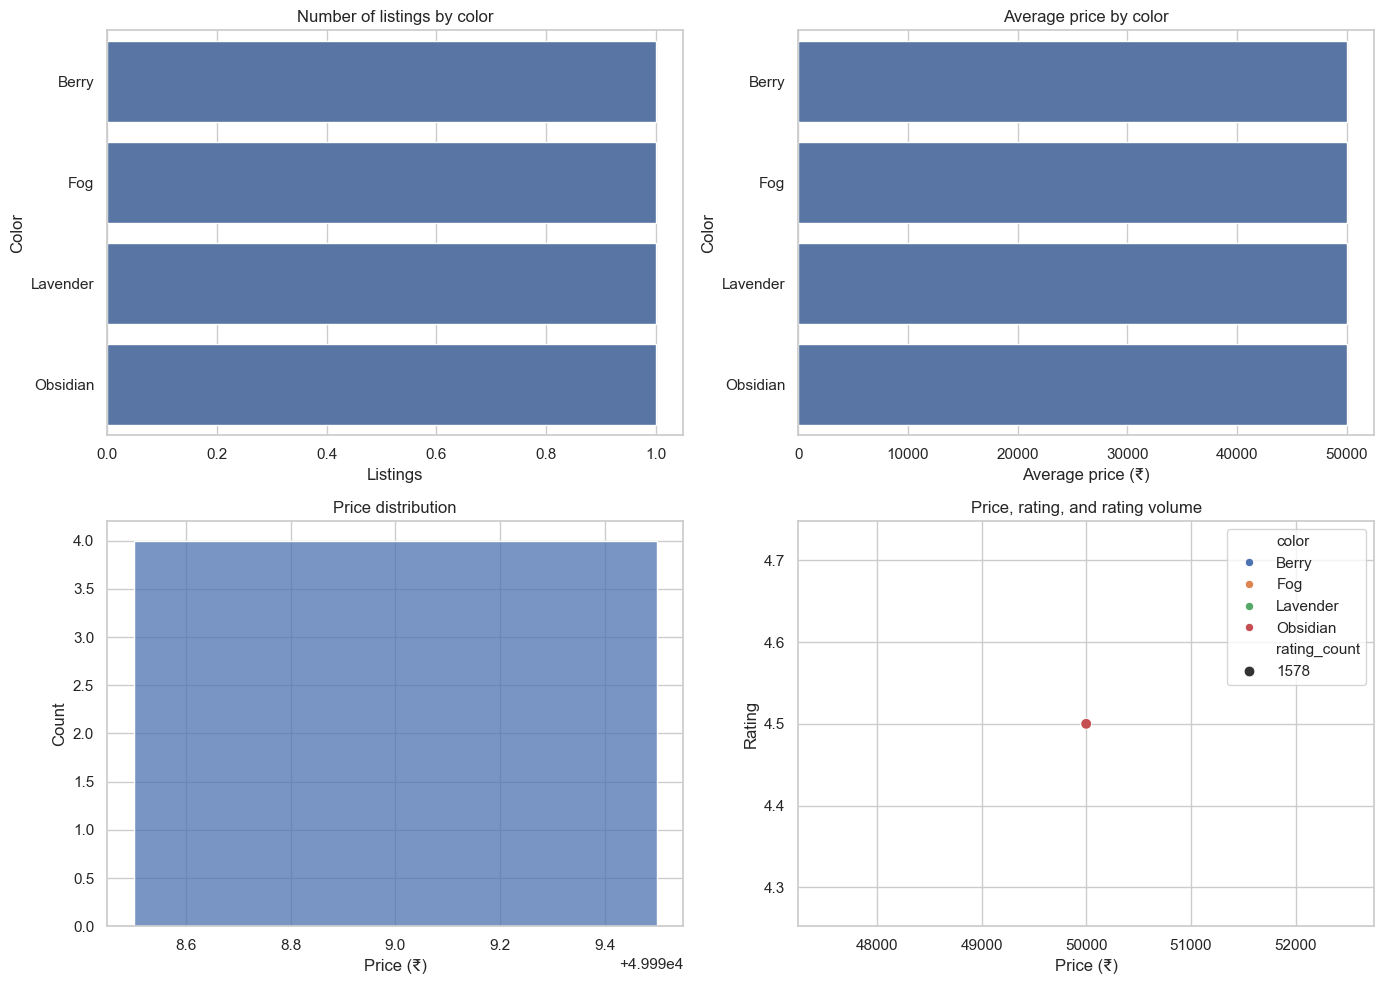

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

color_order = df["color"].value_counts().index
sns.countplot(data=df, y="color", order=color_order, ax=axes[0, 0])
axes[0, 0].set_title("Number of listings by color")
axes[0, 0].set_xlabel("Listings")
axes[0, 0].set_ylabel("Color")

sns.barplot(data=df, x="price_inr", y="color", estimator=np.mean, errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Average price by color")
axes[0, 1].set_xlabel("Average price (₹)")
axes[0, 1].set_ylabel("Color")

sns.histplot(data=df, x="price_inr", bins=min(8, max(1, df["price_inr"].nunique())), ax=axes[1, 0])
axes[1, 0].set_title("Price distribution")
axes[1, 0].set_xlabel("Price (₹)")

sns.scatterplot(data=df, x="price_inr", y="rating", size="rating_count", hue="color", sizes=(60, 350), ax=axes[1, 1])
axes[1, 1].set_title("Price, rating, and rating volume")
axes[1, 1].set_xlabel("Price (₹)")
axes[1, 1].set_ylabel("Rating")

plt.tight_layout()
plt.show()

8. Presentation-ready impact dashboard
These visuals turn the scraped data into a concise story for a presentation:
Choice: number of available color variants.
Affordability: current entry price and price spread.
Trust: customer rating and displayed review volume.
Consistency: whether buyers pay different prices for different colors.

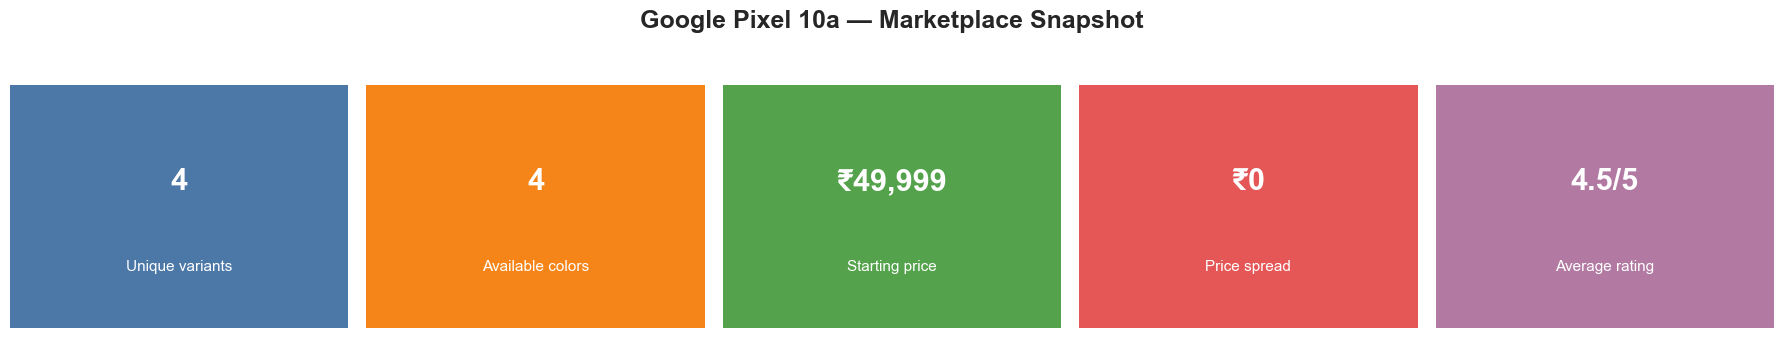

In [64]:
# Presentation KPIs
variant_count = len(df)
color_count = df["color"].nunique()
min_price = df["price_inr"].min()
max_price = df["price_inr"].max()
price_spread = max_price - min_price
average_rating = df["rating"].mean()
displayed_ratings = df["rating_count"].max()

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
kpis = [
    ("Unique variants", variant_count, "#4C78A8"),
    ("Available colors", color_count, "#F58518"),
    ("Starting price", f"₹{min_price:,.0f}", "#54A24B"),
    ("Price spread", f"₹{price_spread:,.0f}", "#E45756"),
    ("Average rating", f"{average_rating:.1f}/5", "#B279A2"),
]

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, str(value), ha="center", va="center",
            fontsize=22, fontweight="bold", color="white")
    ax.text(0.5, 0.25, label, ha="center", va="center",
            fontsize=11, color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Google Pixel 10a — Marketplace Snapshot", fontsize=18, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("pixel_10a_kpi_cards.png", dpi=300, bbox_inches="tight")
plt.show()

,color,price_inr,rating,rating_count,ram,storage,battery,processor
0,Berry,49999,4.5,1578,8 GB,256 GB,5100 mAh Lithium Battery,Tensor G4 Processor
1,Fog,49999,4.5,1578,8 GB,256 GB,5100 mAh Lithium Battery,Tensor G4 Processor
2,Lavender,49999,4.5,1578,8 GB,256 GB,5100 mAh Lithium Battery,Tensor G4 Processor
3,Obsidian,49999,4.5,1578,8 GB,256 GB,5100 mAh Lithium Battery,Tensor G4 Processor


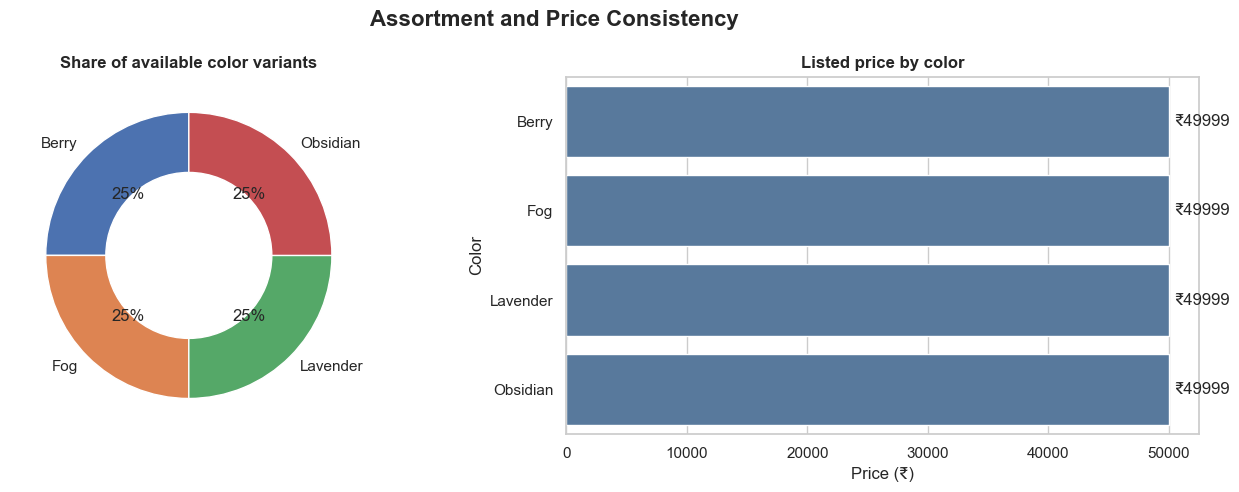

In [65]:
# Variant-level comparison for a presentation slide
presentation_table = (
    df[["color", "price_inr", "rating", "rating_count", "ram", "storage", "battery", "processor"]]
      .sort_values(["price_inr", "color"])
      .reset_index(drop=True)
)
show(presentation_table)
presentation_table.to_csv("pixel_10a_presentation_table.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_counts = df["color"].fillna("Unknown").value_counts()
axes[0].pie(
    color_counts.values,
    labels=color_counts.index,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
axes[0].set_title("Share of available color variants", fontweight="bold")

comparison = df.sort_values("price_inr")
sns.barplot(data=comparison, x="price_inr", y="color", ax=axes[1], color="#4C78A8")
axes[1].set_title("Listed price by color", fontweight="bold")
axes[1].set_xlabel("Price (₹)")
axes[1].set_ylabel("Color")
axes[1].bar_label(axes[1].containers[0], fmt="₹%.0f", padding=4)

fig.suptitle("Assortment and Price Consistency", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("pixel_10a_variant_impact.png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
price_message = (
    "All observed colors have the same listed price, suggesting consistent pricing across variants."
    if price_spread == 0
    else f"The observed price gap is ₹{price_spread:,.0f}; buyers may save by comparing colors or sellers."
)

rating_message = (
    "Customer sentiment is strong."
    if average_rating >= 4.2
    else "Customer sentiment is moderate and reviews should be examined before purchase."
)

findings = [
    f"Flipkart showed {variant_count} unique Pixel 10a listings across {color_count} colors.",
    f"The observed price range was ₹{min_price:,.0f}–₹{max_price:,.0f}.",
    price_message,
    f"The average displayed rating was {average_rating:.1f}/5, supported by up to {displayed_ratings:,.0f} ratings.",
    rating_message,
    "The search page also contained unrelated phones; exact product filtering was necessary for reliable conclusions.",
]

print("PRESENTATION FINDINGS")
print("=" * 60)
for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}")

pd.DataFrame({"finding": findings}).to_csv(
    "pixel_10a_presentation_findings.csv", index=False, encoding="utf-8-sig"
)

PRESENTATION FINDINGS
1. Flipkart showed 4 unique Pixel 10a listings across 4 colors.
2. The observed price range was ₹49,999–₹49,999.
3. All observed colors have the same listed price, suggesting consistent pricing across variants.
4. The average displayed rating was 4.5/5, supported by up to 1,578 ratings.
5. Customer sentiment is strong.
6. The search page also contained unrelated phones; exact product filtering was necessary for reliable conclusions.


10. Methodology and limitations slide
Method: Scraped product cards from the supplied Flipkart search results, retained exact Google Pixel 10a matches, converted numeric fields, and removed duplicate product IDs.


Data-quality impact: Exact-title filtering prevents unrelated recommended phones from distorting the results. Card-level parsing prevents specifications from shifting into the wrong rows when a field is missing.


Limitations: Prices and availability are a time-specific snapshot. Ratings may be shared across color variants, so displayed rating counts should not be added together. The analysis represents Flipkart listings, not the entire smartphone market.

11. Observations template

After running the notebook, describe:
* How many unique Pixel 10a variants were found?
* Which colors were available?
* Did price differ by color or listing?
* What were the average rating and engagement levels?
* Were any specifications or values missing?

Because this is a focused product query, a small number of unique variants is normal. Duplicate cards are not independent observations and should not be counted as separate products.